# Step 08 — did the corrections work? Measured without pooling anything

**Data type: RNA_array** (GSE65391). **Reads:** `step04_site_*` (the truth), `step05_site_*` (with
site effect), `step06_site_*` (federated ComBat), `step07_site_*` (location and scale).
**Writes:** `step08_comparison.rds`, `figures/fig08_RNA_array_sites_pca.png`.

In a simulation each site knows its own data before the planted effect, so every measure below can be
computed from per-site sums. No sample leaves a site, even here.

- **site R²**: average share of a gene's variance explained by site. Zero means site says nothing
  about expression. From each site's per-gene n, sum and sum of squares.
- **error**: mean absolute difference from the truth, log2 scale. Each site sends one sum and one count.
- **error, centred**: the same after centring every gene on its overall mean. The average of the
  three planted shifts moves every sample of a gene by the same amount; no correction can know it, and
  it changes no comparison between samples. This column is the one that matters.
- **gene-wise r**: correlation of each gene's corrected values with its true values across all
  samples, averaged over genes. From per-gene sums of x, t, x², t² and x·t at each site.

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
start_log("08")
VERSIONS <- c(truth = "04", "with site effect" = "05", "federated ComBat" = "06",
              "location and scale" = "07")
genes <- readRDS(art("step04_genes.rds"))

In [2]:
# one message per site and version: per-gene sums, and two scalars
site_msg <- function(s, step) {
  v <- readRDS(site_file(step, s))$E; t <- readRDS(site_file("04", s))$E
  send(list(n = ncol(v), sx = rowSums(v), sxx = rowSums(v^2), st = rowSums(t),
            stt = rowSums(t^2), sxt = rowSums(v * t), abs_err = sum(abs(v - t)), cells = length(v)),
       s, paste("comparison sums", step), ncol(v))
}
score <- function(step) {
  m  <- lapply(SITES, site_msg, step = step)
  n  <- sum(sapply(m, `[[`, "n"))
  S  <- function(k) Reduce(`+`, lapply(m, `[[`, k))
  mx <- S("sx") / n; mt <- S("st") / n
  tot     <- S("sxx") - n * mx^2
  between <- Reduce(`+`, lapply(m, function(x) x$n * (x$sx / x$n - mx)^2))
  cov_xt  <- S("sxt") - n * mx * mt
  r       <- cov_xt / sqrt(tot * (S("stt") - n * mt^2))
  # centred error needs the overall means, which the coordinator sends back
  cen <- sum(sapply(SITES, function(s) {
    v <- readRDS(site_file(step, s))$E; t <- readRDS(site_file("04", s))$E
    send(sum(abs((v - mx) - (t - mt))), s, paste("centred error sum", step), ncol(v))
  }))
  cells <- sum(sapply(m, `[[`, "cells"))
  c(site_R2 = mean(between / tot), error = sum(sapply(m, `[[`, "abs_err")) / cells,
    error_centred = cen / cells, genewise_r = mean(r))
}
metrics <- t(sapply(VERSIONS, score))
round(metrics, 4)

,site_R2,error,error_centred,genewise_r
truth,0.0037,0.0000,0.0000,1.0000
with site effect,0.4830,0.3313,0.2745,0.6524
federated ComBat,0.0000,0.1947,0.0394,0.9862
location and scale,0.0000,0.1949,0.0399,0.9828


## The picture, federated

PCA of the expressed genes, computed federated (step 11 explains the method). Each site projects its
own samples onto the shared components and sends a **density grid**: how many of its samples fall in
each small square of the PC1–PC2 plane, smoothed. The coordinator draws one contour per site. No
sample's coordinates leave its site.

In [3]:
expr <- genes$keep[genes$expressed]
site_density <- function(step) {
  X   <- lapply(setNames(SITES, SITES), function(s) readRDS(site_file(step, s))$E[expr, ])
  ps  <- pool_suff(lapply(names(X), function(s) send(site_suff(X[[s]]), s, "pca: per-gene sums", ncol(X[[s]]))))
  pc  <- federated_pca(X, ps$mean, ps$n, k = 2, oversample = 8, tol = 1e-8)
  lim <- 4 * pc$sdev
  lapply(names(X), function(s) {
    sc <- t(X[[s]] - ps$mean) %*% pc$rotation
    send(density_grid(sc[, 1], sc[, 2], lims = c(-lim[1], lim[1], -lim[2], lim[2])),
         s, "pca density grid", ncol(X[[s]]))
  })
}
dens <- lapply(VERSIONS, site_density)

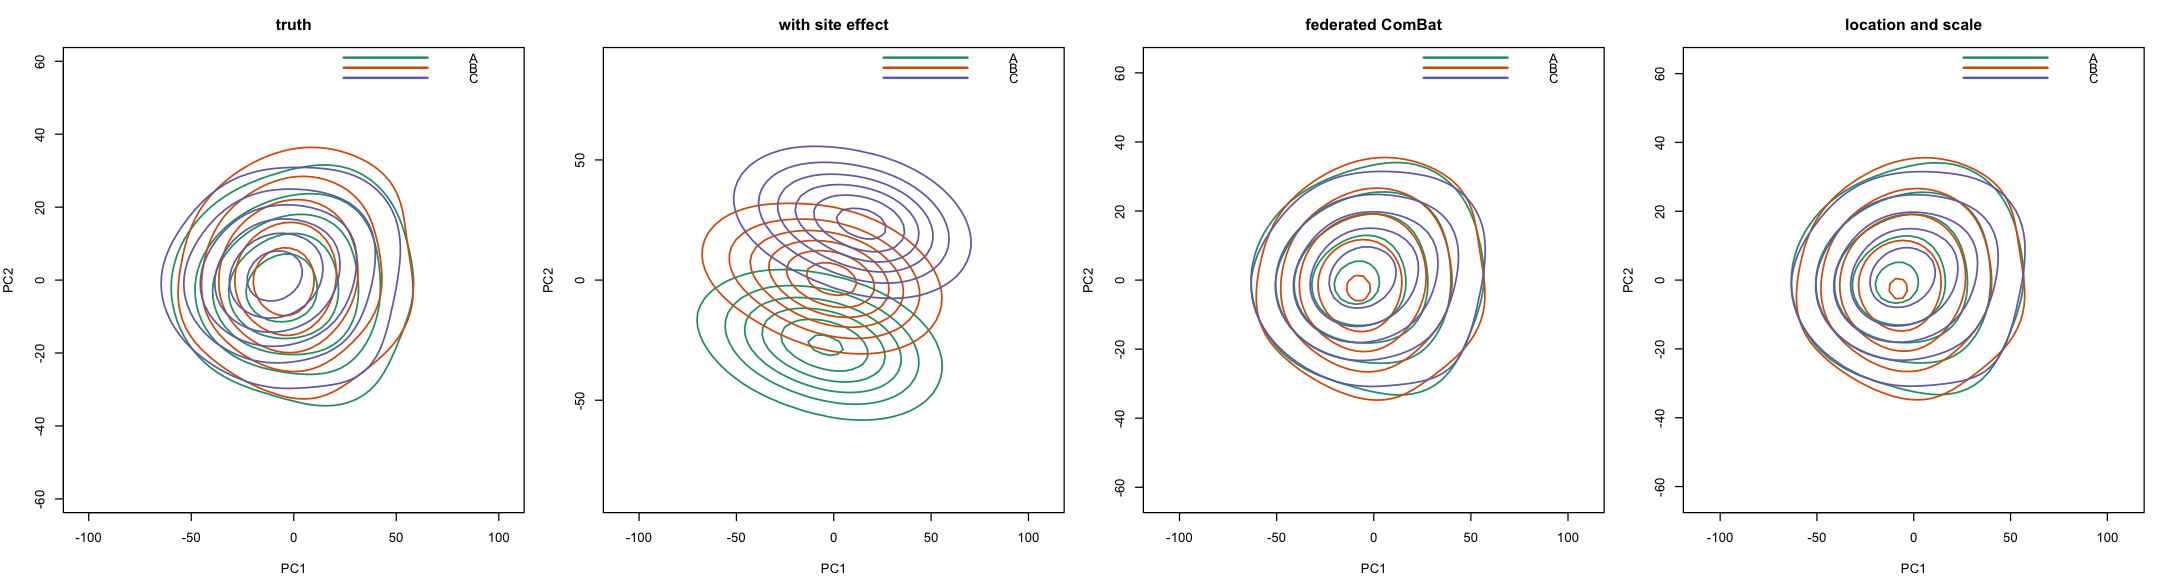

In [4]:
COLS <- c(A = "#1b9e77", B = "#d95f02", C = "#7570b3")
draw_pca <- function() {
  op <- par(mfrow = c(1, 4), mar = c(4, 4, 3, 1))
  for (v in names(dens)) {
    plot(NULL, xlim = range(dens[[v]][[1]]$x), ylim = range(dens[[v]][[1]]$y),
         xlab = "PC1", ylab = "PC2", main = v)
    for (i in seq_along(SITES))
      contour(dens[[v]][[i]], add = TRUE, col = COLS[i], drawlabels = FALSE, nlevels = 6, lwd = 1.4)
    legend("topright", SITES, col = COLS, lwd = 2, bty = "n")
  }
  par(op)
}
png(fig("fig08_RNA_array_sites_pca.png"), width = 2400, height = 650, res = 150); draw_pca(); invisible(dev.off())
options(repr.plot.width = 18, repr.plot.height = 4.8); draw_pca()

## What we carry forward

**Federated ComBat (step 06).** It is exact, it is the standard method, and it needs only one round of
summaries.

In [5]:
saveRDS(list(metrics = metrics, carried_forward = "06"), art("step08_comparison.rds"))

## Findings

The planted effect makes site explain about half of every gene's variance and separates the sites in
the PCA. Both federated corrections bring site R² to zero and the gene-wise correlation with the truth
back to about 0.98. The remaining centred error, about 0.04 log2 units, is the cost of estimating each
site's shift and scale from data.